# Chapter 1: LinTS

## Part 1: The Original LinTS Algorithm

In a contextual bandit system, we observe context, choose one action, and only see reward for that chosen action. Linear Thompson Sampling (LinTS) solves this by maintaining a Bayesian posterior over action-specific linear coefficients and sampling from that posterior to make decisions.

Instead of adding a deterministic confidence bonus (as in UCB), LinTS uses posterior sampling: actions with higher uncertainty naturally get sampled more often, which creates exploration automatically.

For each action $a$, LinTS tracks:
1. Covariance memory matrix: $A_a$
2. Reward vector: $b_a$

At each step:
1. Build context vector $x_t$
2. Compute $A_a^{-1}$ and $\hat{\theta}_a = A_a^{-1}b_a$
3. Sample $\tilde{\theta}_a \sim \mathcal{N}(\hat{\theta}_a, v^2 A_a^{-1})$
4. Score each action with $x_t^\top \tilde{\theta}_a$ and choose max
5. Update only chosen action with observed reward

## Part 2: Engineering Modifications for Production

Vanilla LinTS faces the same production constraints as textbook LinUCB:
1. Infinite memory can make adaptation too slow in non-stationary environments.
2. Repeated matrix inversion is expensive at scale.

FastLinTS introduces two practical upgrades:
1. Exponential discounting via $\gamma$ to forget stale history.
2. Sherman-Morrison rank-1 updates to track $A_a^{-1}$ directly.

This yields a fast and adaptive Thompson Sampling variant suitable for live systems.


STATIC SIMULATION: Single-Seed LinTS vs FastLinTS

MULTI-SEED BENCHMARK: 1 seeds, 2 agents

[Seed 1/1] env_seed=100

1. Launching LinTSAgent online simulation for 35000 riders...
   -> Step 5000: Recent Avg Conversion Rate = 40.4%
      Cumulative Regret: 28.30
      Recent Prediction RMSE: 0.0495
   -> Step 10000: Recent Avg Conversion Rate = 40.9%
      Cumulative Regret: 32.04
      Recent Prediction RMSE: 0.0170
   -> Step 15000: Recent Avg Conversion Rate = 40.6%
      Cumulative Regret: 35.57
      Recent Prediction RMSE: 0.0161
   -> Step 20000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 38.69
      Recent Prediction RMSE: 0.0150
   -> Step 25000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 39.92
      Recent Prediction RMSE: 0.0115
   -> Step 30000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 40.95
      Recent Prediction RMSE: 0.0114
   -> Step 35000: Recent Avg Conversion Rate = 40.3%
      Cumulative Regret: 42.05
      Recen

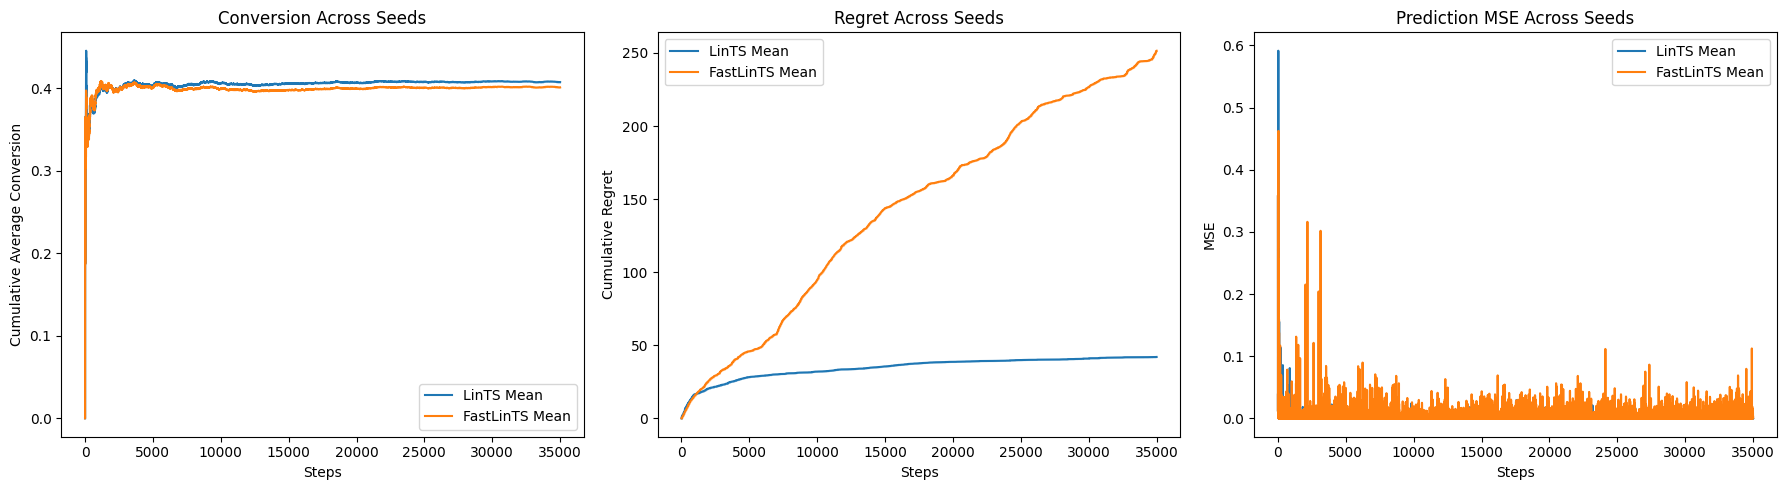

In [1]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path

cwd = Path.cwd()
parent_dir = str(cwd.parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from caudyn.oco.experiments import run_multi_seed_comparison
from caudyn.oco.lints_agents import FastLinTSAgent, LinTSAgent
from caudyn.oco.reporting import plot_multi_seed_comparison, print_multi_seed_summary

print('\n' + '=' * 70)
print('STATIC SIMULATION: Single-Seed LinTS vs FastLinTS')
print('=' * 70)

agent_configs = {
    'LinTS': {'class': LinTSAgent, 'kwargs': {'v_squared': 0.1}},
    'FastLinTS': {'class': FastLinTSAgent, 'kwargs': {'v_squared': 0.1, 'gamma': 0.995}},
}

single_seed_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=[100],
    n_steps=35000,
    progress_every=5000,
)

print_multi_seed_summary(single_seed_result)
plot_multi_seed_comparison(single_seed_result)
plt.show()


MULTI-SEED BENCHMARK: 5 seeds, 2 agents

[Seed 1/5] env_seed=100

1. Launching LinTSAgent online simulation for 35000 riders...
   -> Step 5000: Recent Avg Conversion Rate = 40.4%
      Cumulative Regret: 28.30
      Recent Prediction RMSE: 0.0495
   -> Step 10000: Recent Avg Conversion Rate = 40.9%
      Cumulative Regret: 32.04
      Recent Prediction RMSE: 0.0170
   -> Step 15000: Recent Avg Conversion Rate = 40.6%
      Cumulative Regret: 35.57
      Recent Prediction RMSE: 0.0161
   -> Step 20000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 38.69
      Recent Prediction RMSE: 0.0150
   -> Step 25000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 39.92
      Recent Prediction RMSE: 0.0115
   -> Step 30000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 40.95
      Recent Prediction RMSE: 0.0114
   -> Step 35000: Recent Avg Conversion Rate = 40.3%
      Cumulative Regret: 42.05
      Recent Prediction RMSE: 0.0110

1. Launching FastLinTSAg

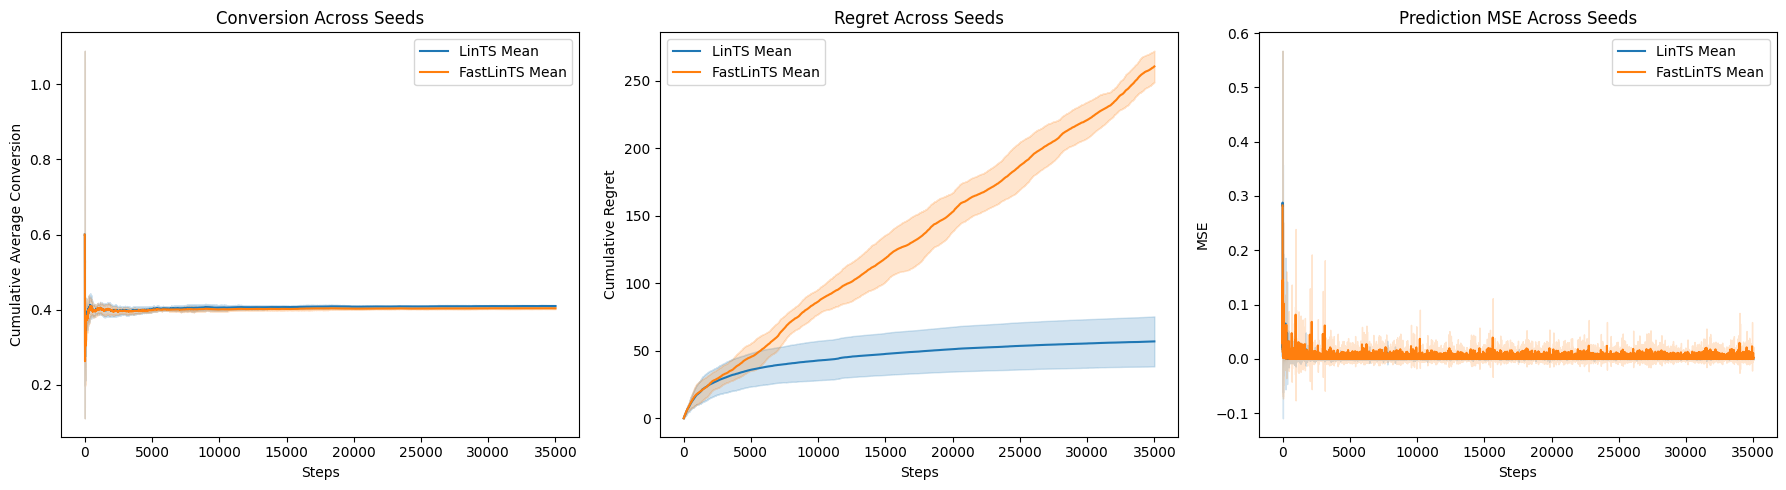

In [2]:
import matplotlib.pyplot as plt

from caudyn.oco.experiments import run_multi_seed_comparison
from caudyn.oco.lints_agents import FastLinTSAgent, LinTSAgent
from caudyn.oco.reporting import plot_multi_seed_comparison, print_multi_seed_summary

# Multi-seed static-environment benchmark
seeds = [100, 101, 102, 103, 104]
n_steps = 35000

agent_configs = {
    'LinTS': {'class': LinTSAgent, 'kwargs': {'v_squared': 0.1}},
    'FastLinTS': {'class': FastLinTSAgent, 'kwargs': {'v_squared': 0.1, 'gamma': 0.995}},
}

multi_seed_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps,
    progress_every=5000,
)

print_multi_seed_summary(multi_seed_result)
plot_multi_seed_comparison(multi_seed_result)
plt.show()

## Part 3: Compact Benchmark Table

### Metric Definitions

$$
\text{Speedup (\%)} = \frac{t_{\text{LinTS}} - t_{\text{FastLinTS}}}{t_{\text{LinTS}}} \times 100
$$

$$
\Delta \text{Regret (\%)} = \frac{R_{\text{FastLinTS}} - R_{\text{LinTS}}}{R_{\text{LinTS}}} \times 100
$$

$$
\Delta \text{Conversion (\%)} = \frac{C_{\text{FastLinTS}} - C_{\text{LinTS}}}{C_{\text{LinTS}}} \times 100
$$

### Results

| Metric | Symbolic Form | Value |
|---|---|---|
| Speedup (%) | $\frac{t_{L} - t_{F}}{t_{L}} \times 100$ | Fill after run |
| Regret Delta (%) | $\frac{R_{F} - R_{L}}{R_{L}} \times 100$ | Fill after run |
| Conversion Delta (%) | $\frac{C_{F} - C_{L}}{C_{L}} \times 100$ | Fill after run |

Use the output from the static multi-seed benchmark cell to fill the Value column.

### Discussion

LinTS and FastLinTS often show very similar conversion trajectories in stationary settings, but their exploration behavior differs in how posterior uncertainty is handled over time.

FastLinTS usually trades a small stationary-environment tax for stronger adaptability in shifting markets because discounting keeps posterior uncertainty from collapsing permanently.

In practice, this is the same production trade-off: slight extra exploration cost in calm periods in exchange for faster recovery after structural change.

# Chapter 2: Non-Stationary Environment - The Shock Test

## Part 1: Engineering the Shock Environment

We evaluate both LinTS variants in `UberMarketplaceEnvironmentWithShock`, where the reward landscape changes abruptly at a configured step.

The objective is to test unlearning speed and recovery quality:
1. Pre-shock: both agents learn a stable policy.
2. Post-shock: the old best action becomes suboptimal.
3. Robust agent behavior means quick posterior adaptation and regret stabilization.


SHOCK SIMULATION: Single-Seed LinTS Adaptability

MULTI-SEED BENCHMARK: 1 seeds, 2 agents

[Seed 1/1] env_seed=100

1. Launching LinTSAgent online simulation for 200000 riders...
   -> Step 50000: Recent Avg Conversion Rate = 30.1%
      Cumulative Regret: 1114.02
      Recent Prediction RMSE: 0.1762
   -> Step 100000: Recent Avg Conversion Rate = 5.5%
      Cumulative Regret: 4473.22
      Recent Prediction RMSE: 0.1888
   -> Step 150000: Recent Avg Conversion Rate = 6.9%
      Cumulative Regret: 7081.58
      Recent Prediction RMSE: 0.1049
   -> Step 200000: Recent Avg Conversion Rate = 8.4%
      Cumulative Regret: 8889.93
      Recent Prediction RMSE: 0.0683

1. Launching FastLinTSAgent online simulation for 200000 riders...
   -> Step 50000: Recent Avg Conversion Rate = 31.2%
      Cumulative Regret: 509.16
      Recent Prediction RMSE: 0.0577
   -> Step 100000: Recent Avg Conversion Rate = 10.6%
      Cumulative Regret: 1298.26
      Recent Prediction RMSE: 0.0347
   -> Step 150

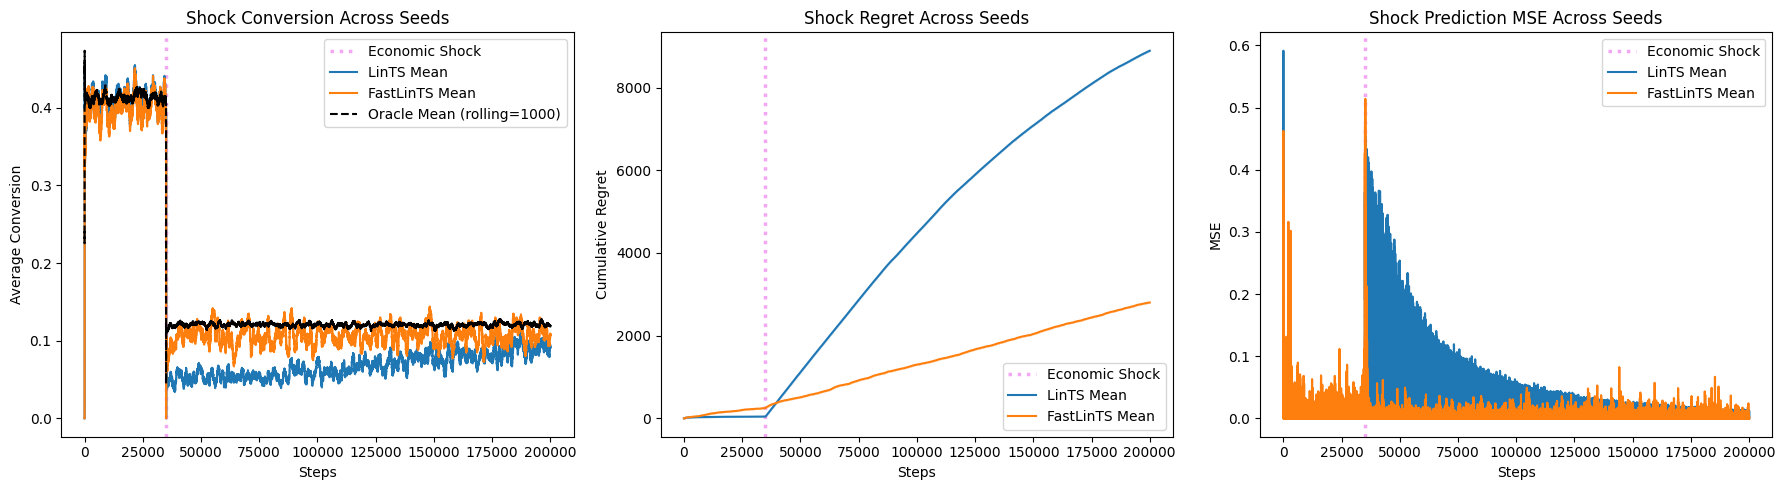

In [3]:
import matplotlib.pyplot as plt

from caudyn.environment import UberMarketplaceEnvironmentWithShock
from caudyn.oco.experiments import run_multi_seed_comparison
from caudyn.oco.lints_agents import FastLinTSAgent, LinTSAgent
from caudyn.oco.reporting import plot_multi_seed_shock_comparison, print_multi_seed_summary

print('\n' + '=' * 70)
print('SHOCK SIMULATION: Single-Seed LinTS Adaptability')
print('=' * 70)

n_steps_shock = 200000
shock_step = 35000

agent_configs = {
    'LinTS': {'class': LinTSAgent, 'kwargs': {'v_squared': 0.1}},
    'FastLinTS': {'class': FastLinTSAgent, 'kwargs': {'v_squared': 0.1, 'gamma': 0.995}},
}

shock_single_seed_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=[100],
    n_steps=n_steps_shock,
    progress_every=50000,
    env_class=UberMarketplaceEnvironmentWithShock,
    env_kwargs={'shock_step': shock_step},
)

print_multi_seed_summary(shock_single_seed_result)
plot_multi_seed_shock_comparison(
    shock_single_seed_result,
    shock_step=shock_step,
    rolling_window=1000,
)
plt.show()


SHOCK SIMULATION: Multi-Seed LinTS Adaptability Benchmark

MULTI-SEED BENCHMARK: 5 seeds, 2 agents

[Seed 1/5] env_seed=100

1. Launching LinTSAgent online simulation for 200000 riders...
   -> Step 50000: Recent Avg Conversion Rate = 30.1%
      Cumulative Regret: 1114.02
      Recent Prediction RMSE: 0.1762
   -> Step 100000: Recent Avg Conversion Rate = 5.5%
      Cumulative Regret: 4473.22
      Recent Prediction RMSE: 0.1888
   -> Step 150000: Recent Avg Conversion Rate = 6.9%
      Cumulative Regret: 7081.58
      Recent Prediction RMSE: 0.1049
   -> Step 200000: Recent Avg Conversion Rate = 8.4%
      Cumulative Regret: 8889.93
      Recent Prediction RMSE: 0.0683

1. Launching FastLinTSAgent online simulation for 200000 riders...
   -> Step 50000: Recent Avg Conversion Rate = 31.2%
      Cumulative Regret: 509.16
      Recent Prediction RMSE: 0.0577
   -> Step 100000: Recent Avg Conversion Rate = 10.6%
      Cumulative Regret: 1298.26
      Recent Prediction RMSE: 0.0347
   ->

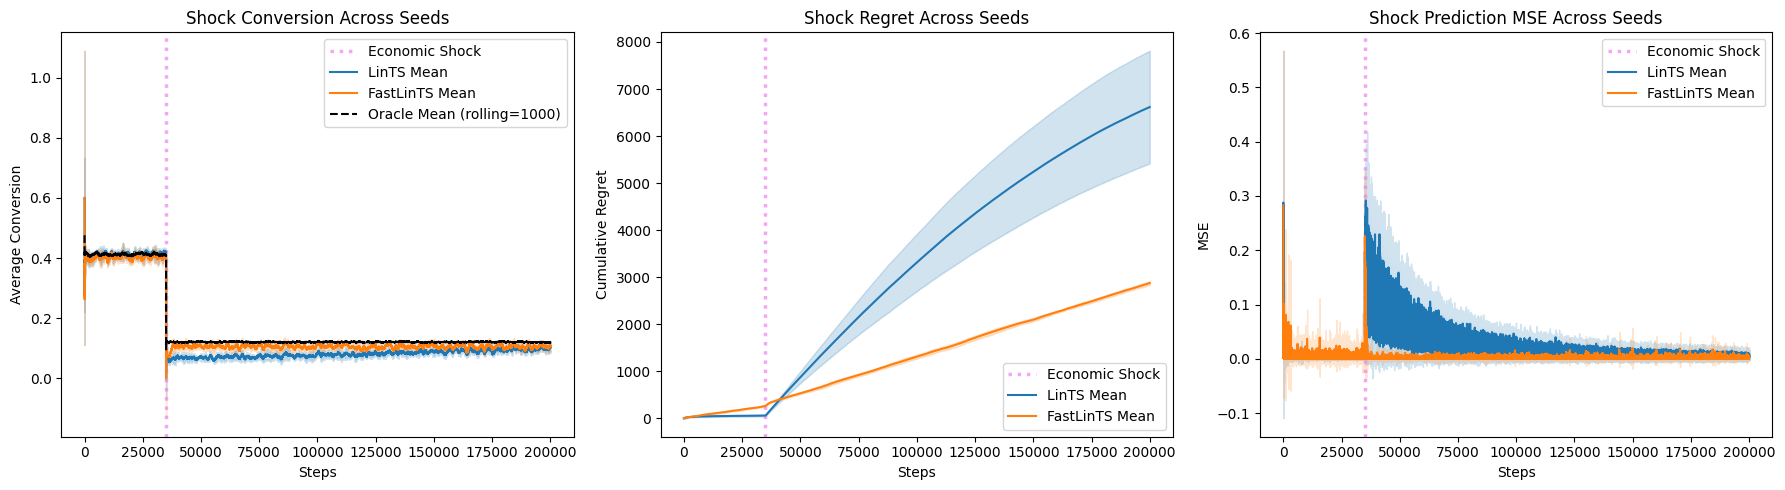

In [4]:
import matplotlib.pyplot as plt

from caudyn.environment import UberMarketplaceEnvironmentWithShock
from caudyn.oco.experiments import run_multi_seed_comparison
from caudyn.oco.lints_agents import FastLinTSAgent, LinTSAgent
from caudyn.oco.reporting import plot_multi_seed_shock_comparison, print_multi_seed_summary

print('\n' + '=' * 70)
print('SHOCK SIMULATION: Multi-Seed LinTS Adaptability Benchmark')
print('=' * 70)

n_steps_shock = 200000
shock_step = 35000
seeds = [100, 101, 102, 103, 104]

agent_configs = {
    'LinTS': {'class': LinTSAgent, 'kwargs': {'v_squared': 0.1}},
    'FastLinTS': {'class': FastLinTSAgent, 'kwargs': {'v_squared': 0.1, 'gamma': 0.995}},
}

shock_multi_seed_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps_shock,
    progress_every=50000,
    env_class=UberMarketplaceEnvironmentWithShock,
    env_kwargs={'shock_step': shock_step},
)

print_multi_seed_summary(shock_multi_seed_result)
plot_multi_seed_shock_comparison(
    shock_multi_seed_result,
    shock_step=shock_step,
    rolling_window=1000,
)
plt.show()

## Part 2: Empirical Analysis

Use the shock multi-seed outputs to compare:
1. Post-shock conversion recovery speed
2. Regret slope before and after adaptation
3. Prediction MSE stabilization

Typical pattern:
- LinTS can adapt, but adaptation may be slower when historical certainty dominates.
- FastLinTS often recovers more reliably because discounting prevents old evidence from fully dominating posterior updates.

# Chapter 3: Cold Start Problem and Warm-Start LinTS

## Part 1: Cold Start Problem

At launch, both LinTS variants start with weak priors and must explore heavily. This creates an expensive day-1 exploration tax.

Warm-starting with offline causal priors can reduce early regret by initializing action-specific linear beliefs closer to reality.

Here we use R-learner-derived linear priors from historical marketplace logs, then inject them into the online agents before simulation starts.

## Part 2: Offline R-Learner Priors

The prior extraction pipeline computes per-arm linear coefficients from offline logs and returns a `prior_bundle` with:
1. `priors`: per-action theta vectors
2. metadata for reproducibility (sample size, CV folds, random state)

These priors are then injected into both LinTS and FastLinTS using `prior_weight` as synthetic evidence strength.

In [5]:
import numpy as np
import pandas as pd

from tabulate import tabulate
from caudyn.oco.experiments import extract_rlearner_linear_priors_from_csv

offline_csv_path = cwd.parent / 'historical_marketplace_logs.csv'
prior_bundle = extract_rlearner_linear_priors_from_csv(
    offline_csv_path=str(offline_csv_path),
    ridge_alpha=1.0,
    rlearner_cv=5,
    rlearner_random_state=100,
)

print('--- R-Learner Prior Extraction ---')
print(f"Offline samples: {prior_bundle['n_samples']}")
print(f"R-learner CV folds: {prior_bundle['rlearner_cv']}")

feature_names = ['intercept'] + prior_bundle['X_columns']
print('Arm Index | ' + ' | '.join(feature_names))
for arm_idx, theta in prior_bundle['priors'].items():
    print(f"Arm {arm_idx} prior theta: {np.round(theta, 4)}")

prior_df = pd.DataFrame.from_dict(
    prior_bundle['priors'],
    orient='index',
    columns=feature_names,
)
print('\nR-Learner Priors Table:')
print(tabulate(prior_df, headers='keys', tablefmt='grid', showindex=True))

--- R-Learner Prior Extraction ---
Offline samples: 100000
R-learner CV folds: 5
Arm Index | intercept | recency | frequency | weather_active | surge_multiplier
Arm 0 prior theta: [ 0.1751 -0.2243  0.7207  0.0849 -0.2526]
Arm 1 prior theta: [ 0.2157 -0.1817  0.6281  0.0821 -0.2076]
Arm 2 prior theta: [ 0.2563 -0.1392  0.5356  0.0793 -0.1627]

R-Learner Priors Table:
+----+-------------+-----------+-------------+------------------+--------------------+
|    |   intercept |   recency |   frequency |   weather_active |   surge_multiplier |
+====+=============+===========+=============+==================+====================+
|  0 |    0.175091 | -0.224267 |    0.720696 |        0.084874  |          -0.25259  |
+----+-------------+-----------+-------------+------------------+--------------------+
|  1 |    0.215673 | -0.181726 |    0.628137 |        0.0820676 |          -0.207624 |
+----+-------------+-----------+-------------+------------------+--------------------+
|  2 |    0.256256 | -


MULTI-SEED BENCHMARK: 5 seeds, 2 agents

[Seed 1/5] env_seed=100

1. Launching LinTSAgent online simulation for 35000 riders...
   -> Step 5000: Recent Avg Conversion Rate = 40.4%
      Cumulative Regret: 28.30
      Recent Prediction RMSE: 0.0495
   -> Step 10000: Recent Avg Conversion Rate = 40.9%
      Cumulative Regret: 32.04
      Recent Prediction RMSE: 0.0170
   -> Step 15000: Recent Avg Conversion Rate = 40.6%
      Cumulative Regret: 35.57
      Recent Prediction RMSE: 0.0161
   -> Step 20000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 38.69
      Recent Prediction RMSE: 0.0150
   -> Step 25000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 39.92
      Recent Prediction RMSE: 0.0115
   -> Step 30000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 40.95
      Recent Prediction RMSE: 0.0114
   -> Step 35000: Recent Avg Conversion Rate = 40.3%
      Cumulative Regret: 42.05
      Recent Prediction RMSE: 0.0110

1. Launching FastLinTSAg

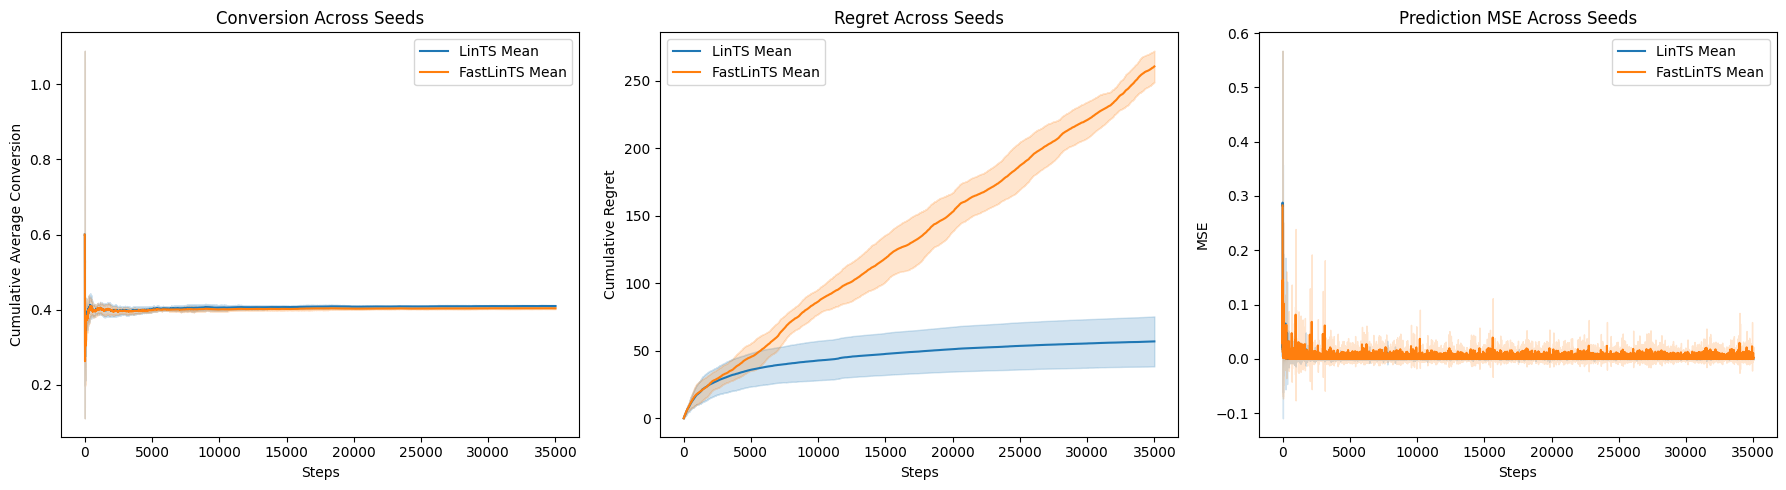


=== Warm-start Curves ===


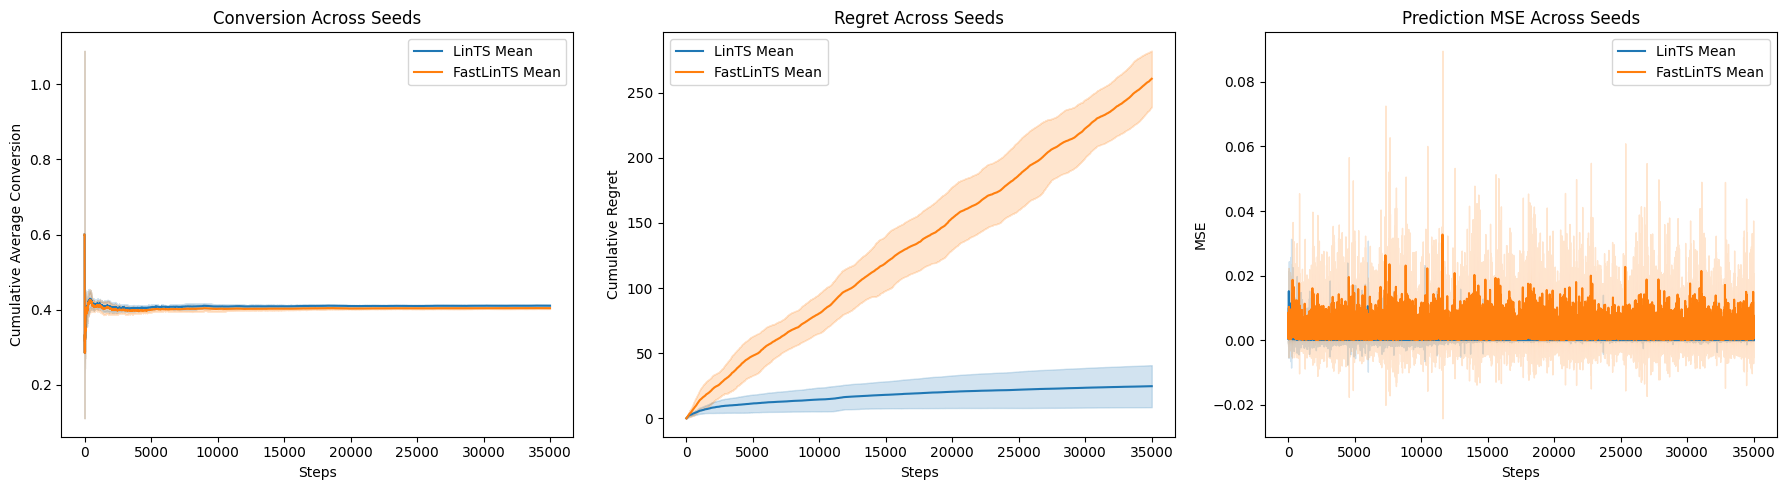


=== Visualization: Cold vs Warm by Variant ===


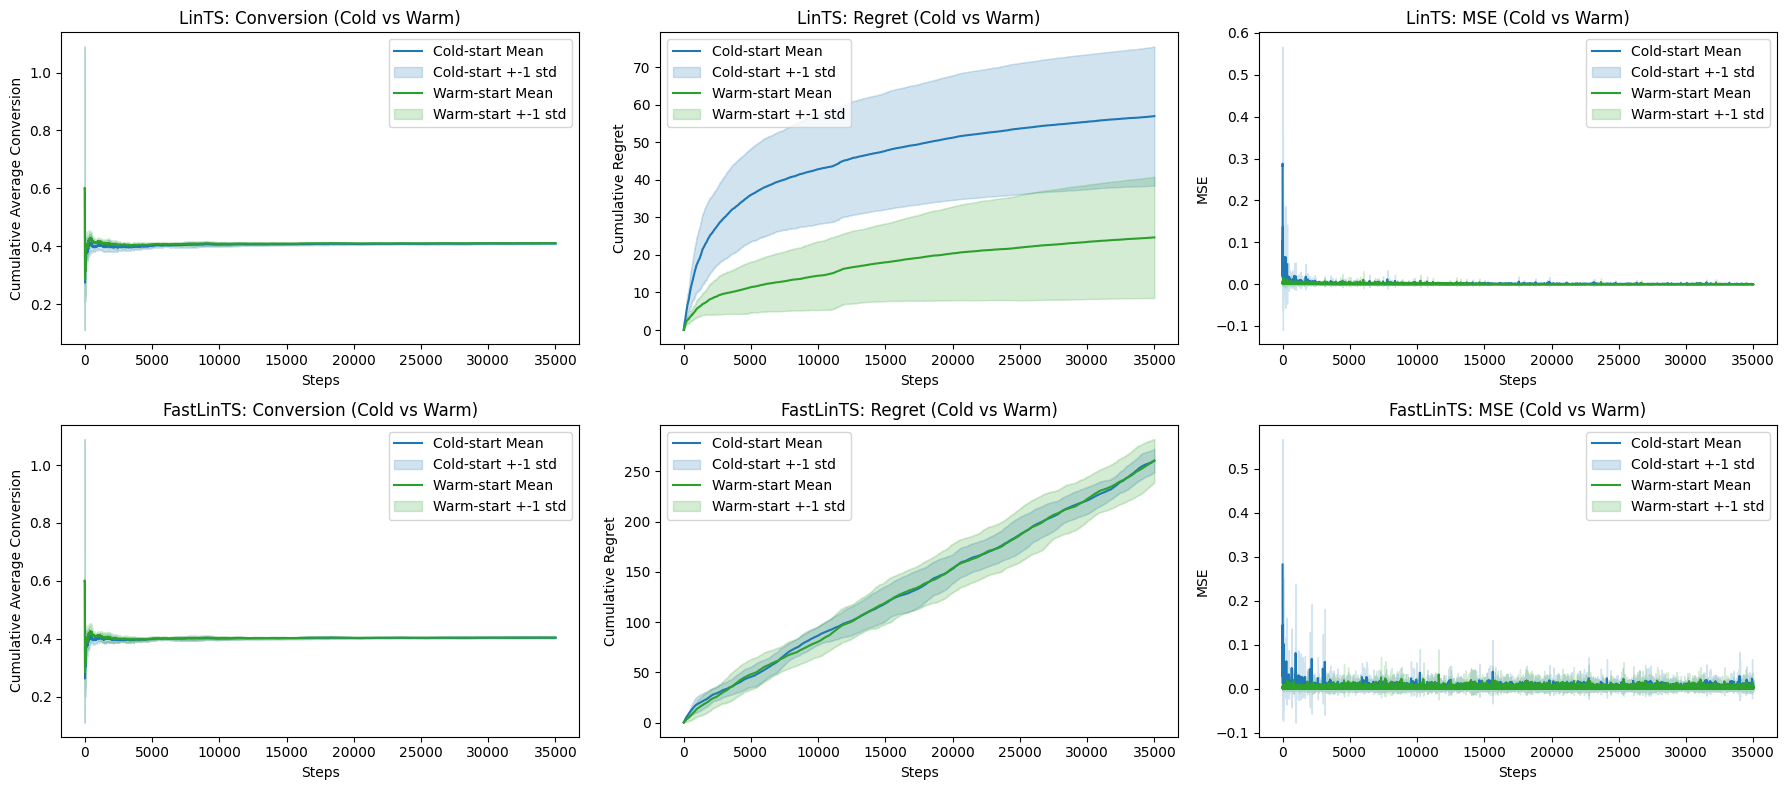

In [6]:
import matplotlib.pyplot as plt

from caudyn.oco.experiments import run_multi_seed_comparison, run_static_warm_start_multi_seed
from caudyn.oco.lints_agents import FastLinTSAgent, LinTSAgent
from caudyn.oco.reporting import plot_cold_vs_warm_start_comparison, plot_multi_seed_comparison, print_multi_seed_summary

seeds = [100, 101, 102, 103, 104]
n_steps = 35000

agent_configs = {
    'LinTS': {'class': LinTSAgent, 'kwargs': {'v_squared': 0.1}},
    'FastLinTS': {'class': FastLinTSAgent, 'kwargs': {'v_squared': 0.1, 'gamma': 0.995}},
}

cold_start_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps,
    progress_every=5000,
)

warm_start_result = run_static_warm_start_multi_seed(
    offline_csv_path=str(offline_csv_path),
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps,
    progress_every=5000,
    prior_weight=30.0,
    ridge_alpha=1.0,
    rlearner_cv=5,
    rlearner_random_state=42,
)

print('\n=== Cold-start Summary ===')
print_multi_seed_summary(cold_start_result)
print('\n=== Warm-start Summary (R-Learner priors) ===')
print_multi_seed_summary(warm_start_result)

print('\n=== Cold-start Curves ===')
plot_multi_seed_comparison(cold_start_result)
plt.show()

print('\n=== Warm-start Curves ===')
plot_multi_seed_comparison(warm_start_result)
plt.show()

print("\n=== Visualization: Cold vs Warm by Variant ===")
plot_cold_vs_warm_start_comparison(cold_start_result, warm_start_result)
plt.show()

## Part 3: Results and Discussion

This section should confirm two outcomes:
1. Warm-start reduces early regret for both LinTS variants.
2. FastLinTS retains adaptability by discounting old evidence over time.

When interpreting long-horizon experiments, prioritize cumulative regret and recovery dynamics over only final average conversion, since averages can hide large early-phase mistakes.